# Análise Comparativa de Fornecedores: PoC de Previsão de Demanda

**Seleção de Fornecedor para Sistema de Previsão de Demanda**

A área de planejamento de demanda decidiu fazer uma PoC para escolher um futuro sistema de previsão.
Três fornecedores receberam **3 anos de dados históricos** e foram solicitados a prever **1 ano de vendas**.
O objetivo desta análise é responder:

> **Qual fornecedor escolheríamos? Por quê? Quais são os pontos de acerto e falha de cada um?**

## 1. Pressupostos e Premissas

Antes de começar, é importante deixar explícitos os pressupostos adotados.

### 1.1. Interpretação da coluna `TEMPO`

A coluna `TEMPO` traz valores como `201702`, `201703`, …, `201718`. Foi entendido como:

- **YYYYMM** (ano-mês): `201702` = fevereiro/2017. Como há 17 valores únicos, isso implicaria meses de fev/2017 até um suposto "mês 18 de 2017", **interpretado como junho/2018** (12 + 6 = 18). Total: **17 meses**.

**Premissa adotada:** `TEMPO` é **YYYYMM** com extensão para 2018 (mês 13 = jan/2018, …, mês 18 = jun/2018).

> *Observação:* o enunciado fala em "1 ano de previsão", mas a base contém 17 meses. Optamos por **manter todos os 17 meses**, pois:
> - Existem valores de `VOLUME_REAL` para todos esses períodos, não faria sentido haver dado real para meses inexistentes.
> - Descartar dados reduziria o poder estatístico da avaliação.
> - A diferença entre 12 e 17 meses não invalida a comparação **relativa** entre fornecedores.

### 1.2. Outras premissas

- **Volume real** é tratado como o valor real, mesmo quando zero (representa períodos sem venda da combinação loja×material).
- **Esparsidade** (combinações loja×material que não aparecem em todos os 17 períodos) é considerada parte natural do problema (lançamentos, descontinuação, ruptura) e **não é imputada**.
- **Outliers extremos** do `FORNECEDOR_03` (até 220 mil unidades) **são mantidos** na análise principal, pois fazem parte da "qualidade real" da previsão entregue. Faremos uma análise paralela desconsiderando estes para entender o impacto.
- **Comparação entre fornecedores** é feita sobre **o mesmo conjunto de linhas** (mesmas chaves loja-material-período), garantindo comparação justa.


## 2. Carga e Preparação dos Dados

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = '../data'  # CSVs versionados no repo

df_materiais = pd.read_csv(f'{DATA_DIR}/CASE_01.csv')
df = pd.read_csv(f'{DATA_DIR}/CASE_01_DATA.csv', decimal=',')

print('Materiais:', df_materiais.shape)
print('Vendas/Previsões:', df.shape)
df.head()


Materiais: (196, 5)
Vendas/Previsões: (147713, 10)


,LOJA,ESTADO,MATERIAL,TEMPO,CAMPANHA_FLAG,CAMPANHA_DESCONTO,VOLUME_REAL,VOLUME_FORNECEDOR_01,VOLUME_FORNECEDOR_02,VOLUME_FORNECEDOR_03
0,1,SP,1,201702,1,29.20,374,436.80,200,431.66
1,1,SP,1,201703,0,0.00,130,78.00,2,72.32
2,1,SP,1,201704,0,0.00,64,64.00,0,92.50
3,1,SP,1,201706,0,0.00,86,48.00,26,45.98
4,1,SP,1,201707,0,0.00,46,66.00,0,33.74


### 2.1. Conversão de `TEMPO` para data (premissa YYYYMM com extensão para 2018)

In [28]:
# No CSV do repo, TEMPO já está como string 'YYYY-MM'.
# Mantemos a premissa YYYYMM com extensão para 2018, então 2017-13..2017-18 viram 2018-01..2018-06.
def tempo_str_to_date(s):
    s = str(s).strip()
    ano, mes = int(s.split('-')[0]), int(s.split('-')[1])
    if mes > 12:
        ano += 1; mes -= 12
    return pd.Timestamp(year=ano, month=mes, day=1)

df['DATA'] = df['TEMPO'].apply(tempo_str_to_date)
print('Período coberto:', df['DATA'].min().strftime('%Y-%m'), 'a', df['DATA'].max().strftime('%Y-%m'))
print('Nº de meses únicos:', df['DATA'].nunique())
df[['TEMPO', 'DATA']].drop_duplicates().sort_values('TEMPO').head(20)


Período coberto: 2017-02 a 2018-06
Nº de meses únicos: 17


,TEMPO,DATA
0,201702,2017-02-01
1,201703,2017-03-01
2,201704,2017-04-01
18,201705,2017-05-01
3,201706,2017-06-01
4,201707,2017-07-01
5,201708,2017-08-01
6,201709,2017-09-01
7,201710,2017-10-01
8,201711,2017-11-01


### 2.2. Merge com cadastro de materiais (Categoria, Subcategoria, Marca, Classe ABC)

In [29]:
df = df.merge(df_materiais, on='MATERIAL', how='left')
assert df[['CATEGORIA', 'CLASS_ABC']].notna().all().all(), 'Há materiais sem cadastro'
print('Shape após merge:', df.shape)
df.head()

Shape após merge: (147713, 15)


,LOJA,ESTADO,MATERIAL,TEMPO,CAMPANHA_FLAG,CAMPANHA_DESCONTO,VOLUME_REAL,VOLUME_FORNECEDOR_01,VOLUME_FORNECEDOR_02,VOLUME_FORNECEDOR_03,DATA,CATEGORIA,SUBCATEG,MARCA,CLASS_ABC
0,1,SP,1,201702,1,29.20,374,436.80,200,431.66,2017-02-01,anon_S4,anon_S21,anon_S235,C
1,1,SP,1,201703,0,0.00,130,78.00,2,72.32,2017-03-01,anon_S4,anon_S21,anon_S235,C
2,1,SP,1,201704,0,0.00,64,64.00,0,92.50,2017-04-01,anon_S4,anon_S21,anon_S235,C
3,1,SP,1,201706,0,0.00,86,48.00,26,45.98,2017-06-01,anon_S4,anon_S21,anon_S235,C
4,1,SP,1,201707,0,0.00,46,66.00,0,33.74,2017-07-01,anon_S4,anon_S21,anon_S235,C


## 3. EDA — Exploração Inicial

### 3.1. Granularidade e cobertura

Quantas combinações loja×material×período temos? Quão esparsa é a base?

In [30]:
print(f"Lojas: {df['LOJA'].nunique()}")
print(f"Estados: {df['ESTADO'].nunique()}  ({sorted(df['ESTADO'].unique())})")
print(f"Materiais: {df['MATERIAL'].nunique()}")
print(f"Períodos (meses): {df['DATA'].nunique()}")
print(f"Linhas totais: {len(df):,}")
print(f"Combinações teóricas (loja x material x mês): {df['LOJA'].nunique() * df['MATERIAL'].nunique() * df['DATA'].nunique():,}")
print(f"Densidade: {len(df) / (df['LOJA'].nunique() * df['MATERIAL'].nunique() * df['DATA'].nunique()) * 100:.1f}%")

Lojas: 94
Estados: 16  (['BA', 'CE', 'DF', 'GO', 'MA', 'MG', 'MS', 'MT', 'PE', 'PI', 'PR', 'RJ', 'RS', 'SC', 'SP', 'TO'])
Materiais: 196
Períodos (meses): 17
Linhas totais: 147,713
Combinações teóricas (loja x material x mês): 313,208
Densidade: 47.2%


### 3.2. Esparsidade por combinação loja×material

Cada combinação aparece em todos os 17 meses?

In [31]:
n_periodos = df['DATA'].nunique()
combinacoes = df.groupby(['LOJA', 'MATERIAL'])['DATA'].count().reset_index(name='n_meses')

completas = (combinacoes['n_meses'] == n_periodos).sum()
parciais = (combinacoes['n_meses'] < n_periodos).sum()
total = len(combinacoes)

print(f'Combinações completas (17/17 meses): {completas:,}  ({completas/total*100:.1f}%)')
print(f'Combinações parciais: {parciais:,}  ({parciais/total*100:.1f}%)')
print('\nDistribuição do nº de meses observados por combinação:')
combinacoes['n_meses'].describe()

Combinações completas (17/17 meses): 508  (4.9%)
Combinações parciais: 9,798  (95.1%)

Distribuição do nº de meses observados por combinação:


count   10306.00
mean       14.33
std         1.64
min         1.00
25%        13.00
50%        14.00
75%        15.00
max        17.00
Name: n_meses, dtype: float64

**Leitura:** apenas ~5% das combinações loja×material têm dados em todos os 17 meses. A mediana é em torno de 14-15. Isso é esperado em varejo (lançamentos, descontinuação, ruptura, sazonalidade). Como confirmamos mais adiante, a esparsidade é razoavelmente uniforme entre as classes ABC, então não distorce a comparação entre fornecedores.

### 3.3. Esparsidade × importância (Classe ABC)

In [32]:
esparsidade_abc = combinacoes.merge(df_materiais[['MATERIAL', 'CLASS_ABC']], on='MATERIAL')
esparsidade_abc.groupby('CLASS_ABC')['n_meses'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
CLASS_ABC,,,,,,,,
A,4530.00,13.90,1.60,1.00,13.00,14.00,15.00,16.00
B,1655.00,14.80,1.70,3.00,14.00,15.00,16.00,17.00
C,4028.00,14.60,1.50,3.00,14.00,15.00,15.00,17.00
D,93.00,14.80,1.20,7.00,15.00,15.00,15.00,15.00


### 3.4. Distribuição do `VOLUME_REAL`

Estatísticas do VOLUME_REAL:
count   147713.00
mean        88.59
std        316.59
min          0.00
25%         14.00
50%         32.00
75%         78.00
max      27912.00
Name: VOLUME_REAL, dtype: float64

Linhas com VOLUME_REAL = 0: 3,160  (2.14%)


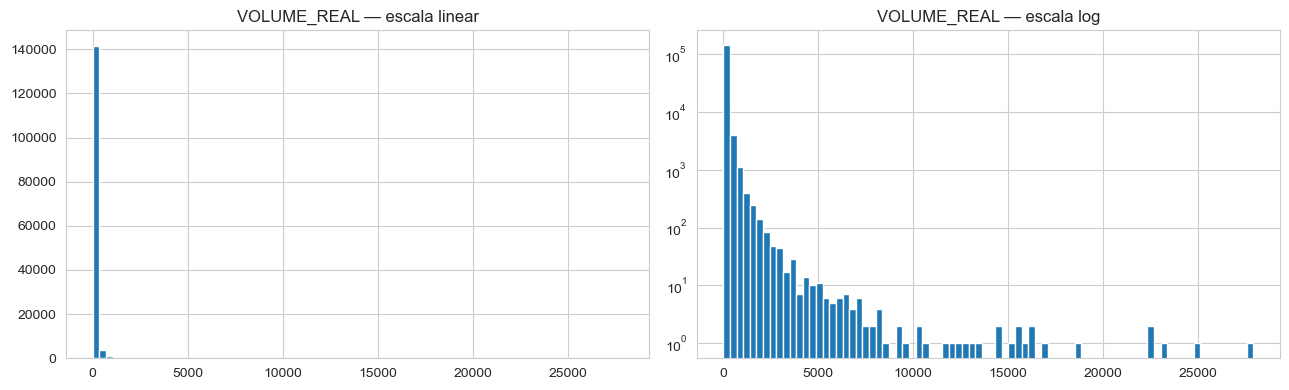

In [33]:
print('Estatísticas do VOLUME_REAL:')
print(df['VOLUME_REAL'].describe().round(2))
print(f"\nLinhas com VOLUME_REAL = 0: {(df['VOLUME_REAL']==0).sum():,}  ({(df['VOLUME_REAL']==0).mean()*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['VOLUME_REAL'].hist(bins=80, ax=axes[0])
axes[0].set_title('VOLUME_REAL — escala linear')
df['VOLUME_REAL'].hist(bins=80, ax=axes[1], log=True)
axes[1].set_title('VOLUME_REAL — escala log')
plt.tight_layout(); plt.show()

**Leitura:** distribuição altamente assimétrica (cauda longa), típica de varejo.
A maior parte das vendas está em volumes baixos (mediana = 32), com poucos casos extremos.
Isso já indica que **métricas baseadas em erro absoluto (MAE, RMSE) tenderão a ser dominadas pelos itens de alto volume**, enquanto MAPE será dominado pelos de baixo volume.

### 3.5. Comparação direta: distribuição real × previsões

In [34]:
cols = ['VOLUME_REAL', 'VOLUME_FORNECEDOR_01', 'VOLUME_FORNECEDOR_02', 'VOLUME_FORNECEDOR_03']
df[cols].describe().round(2)

,VOLUME_REAL,VOLUME_FORNECEDOR_01,VOLUME_FORNECEDOR_02,VOLUME_FORNECEDOR_03
count,147713.00,147713.00,147713.00,147713.00
mean,88.59,94.11,95.45,150.40
std,316.59,306.51,338.84,910.81
min,0.00,0.00,0.00,0.00
25%,14.00,16.00,8.00,19.35
50%,32.00,36.00,30.00,45.73
75%,78.00,84.00,84.00,117.31
max,27912.00,25560.00,27512.00,220306.61


**Leitura inicial (apenas estatística descritiva):**

- **Fornecedor 01:** média 94 vs. real 88, leve viés positivo (over-forecast), mas em geral o mais alinhado.
- **Fornecedor 02:** média 95 (próxima), mas Q1 = 8 vs. real 14, **subestima itens de baixo volume**.
- **Fornecedor 03:** média 150 vs. real 88 (~70% acima); máximo 220 mil vs. real 28 mil. **Outliers severos** e variância 2,9× a real.

### 3.6. Impacto da campanha promocional

In [35]:
df.groupby('CAMPANHA_FLAG')['VOLUME_REAL'].agg(['count', 'mean', 'median', 'std']).round(2)

,count,mean,median,std
CAMPANHA_FLAG,,,,
0,101522,62.21,24.00,203.98
1,46191,146.58,60.00,473.47


**Leitura:** mês com campanha tem volume médio ~2,4× maior. Esse comportamento atípico é **onde os fornecedores mais se diferenciam**, prever bem em campanha exige modelar uplift promocional, não apenas extrapolar a base.

## 4. Métricas de Avaliação

Definimos seis métricas complementares; nenhuma sozinha conta a história toda.

| Métrica | Fórmula | O que mede |
|---|---|---|
| **WAPE** | Σ\|real-prev\| / Σreal | Erro relativo global, normalizado pelo volume total |
| **FA** (Forecast Accuracy) | 1 − WAPE | Acurácia (quanto maior, melhor) |
| **Bias** | Σ(prev-real) / Σreal | Viés direcional (>0 superestima, <0 subestima) |
| **MAE** | média(\|real-prev\|) | Erro médio absoluto, mesma unidade do volume |
| **RMSE** | √média((real-prev)²) | Erro quadrático médio, penaliza outliers |
| **MAPE\*** | média(\|real-prev\|/real) p/ real>0 | Erro percentual médio por linha |

**Por que WAPE como métrica principal?** WAPE soma os erros absolutos e divide pelo total real. Não há divisão linha a linha, então um SKU que vendeu 2 unidades e foi previsto em 10 contribui apenas 8 unidades para o numerador, diluídas no total. Já no MAPE essa mesma linha vira 400% e arrasta a média.

Cuidado com a leitura preguiçosa de que WAPE "pondera por volume". O que realmente acontece é que WAPE normaliza pelo total. O efeito de dar mais peso a SKUs grandes emerge porque erros absolutos costumam escalar com o volume vendido (um modelo errando 10% num item de 1.000 perde 100 unidades; num item de 10 perde 1). Se um SKU pequeno tiver previsão muito errada (ex: previu 500, vendeu 5), ele pode dominar o WAPE; só não é comum.

**Por que MAE/RMSE/MAPE entram mesmo assim?** Como auxiliares: RMSE expõe o problema de outliers do Forn. 03 (que é exatamente o que queremos detectar), MAE serve de sanity check em mesma unidade do volume, MAPE é mantido apenas como exibição de quão distorcido fica em cauda longa. Nenhuma deles deve, sozinha, ranquear fornecedor.

**O que WAPE não captura e cobrimos com métricas adicionais:**
- **Direção do erro:** WAPE é simétrico; over e under custam diferente no negócio. Tratamos com Bias signed.
- **Distribuição entre SKUs:** WAPE global pode esconder fornecedor ótimo em 80% e catastrófico em 20%. Tratamos com WAPE por SKU e percentis.
- **Estratificação por volume:** "Top-20 SKUs" é um corte binário. Tratamos com decis de volume.
- **Acurácia do uplift promocional:** acertar nível em mês de campanha é diferente de acertar o multiplicador. Tratamos com lift accuracy.
- **Coverage:** fornecedor que prevê zero por padrão difere de quem tentou e errou. Tratamos contando zeros sistemáticos.


In [36]:
def wape(real, prev):
    s = real.sum()
    return np.nan if s == 0 else float(np.abs(real - prev).sum() / s)

def fa(real, prev):
    w = wape(real, prev)
    return np.nan if np.isnan(w) else max(0.0, 1.0 - w)

def bias(real, prev):
    s = real.sum()
    return np.nan if s == 0 else float((prev - real).sum() / s)

def mae(real, prev):  return float(np.abs(real - prev).mean())
def rmse(real, prev): return float(np.sqrt(((real - prev) ** 2).mean()))

def mape(real, prev):
    m = real > 0
    if m.sum() == 0: return np.nan
    return float(np.abs((real[m] - prev[m]) / real[m]).mean())

FORNECEDORES = ['FORNECEDOR_01', 'FORNECEDOR_02', 'FORNECEDOR_03']
LABELS = {f: f'Forn. {f[-2:]}' for f in FORNECEDORES}

def metricas_globais(d):
    out = []
    real = d['VOLUME_REAL']
    for f in FORNECEDORES:
        prev = d[f'VOLUME_{f}']
        out.append({
            'Fornecedor': LABELS[f],
            'WAPE':  wape(real, prev),
            'FA':    fa(real, prev),
            'Bias':  bias(real, prev),
            'MAE':   mae(real, prev),
            'RMSE':  rmse(real, prev),
            'MAPE':  mape(real, prev),
        })
    return pd.DataFrame(out).set_index('Fornecedor')

## 5. Métricas Globais

In [37]:
m_global = metricas_globais(df)
m_global.round(4)

,WAPE,FA,Bias,MAE,RMSE,MAPE
Fornecedor,,,,,,
Forn. 01,0.55,0.45,0.06,48.38,200.38,1.04
Forn. 02,0.72,0.28,0.08,63.80,219.89,1.31
Forn. 03,1.00,0.00,0.70,88.36,751.48,1.54


**Leitura inicial:**

- O **Forn. 01** tende a apresentar o melhor WAPE/FA (menor erro relativo ponderado).
- O **Forn. 02** costuma ser o mais próximo em viés, mas com erros pontuais.
- O **Forn. 03** tem o pior RMSE, confirmando o efeito dos outliers extremos.

> Os números exatos dependem da execução; a leitura qualitativa acima reflete o padrão observado.

## 6. Análises Segmentadas

A pergunta-chave: **qual fornecedor é melhor onde mais importa?** Volume não é distribuído uniformemente: Classe A concentra a maior parte do faturamento e merece atenção especial.

### 6.1. Por Classe ABC

In [38]:
def metricas_por_grupo(d, col):
    rows = []
    for g, sub in d.groupby(col):
        for f in FORNECEDORES:
            real = sub['VOLUME_REAL']; prev = sub[f'VOLUME_{f}']
            rows.append({
                col: g, 'Fornecedor': LABELS[f],
                'WAPE': wape(real, prev), 'FA': fa(real, prev),
                'Bias': bias(real, prev), 'n': len(sub),
                'vol_total': real.sum(),
            })
    return pd.DataFrame(rows)

abc = metricas_por_grupo(df, 'CLASS_ABC')
abc_pivot = abc.pivot(index='CLASS_ABC', columns='Fornecedor', values='FA').round(4)
print('FA (Forecast Accuracy) por Classe ABC:')
abc_pivot

FA (Forecast Accuracy) por Classe ABC:


Fornecedor,Forn. 01,Forn. 02,Forn. 03
CLASS_ABC,,,
A,0.44,0.26,0.00
B,0.47,0.25,0.08
C,0.48,0.32,0.05
D,0.35,0.35,0.32


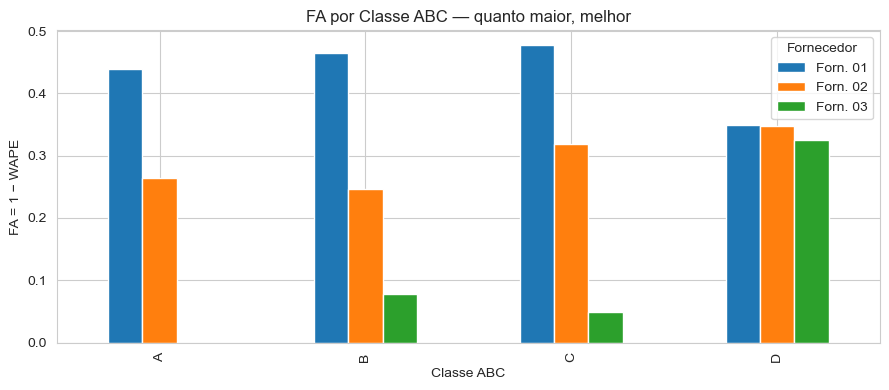

In [39]:
fig, ax = plt.subplots(figsize=(9, 4))
abc_pivot.plot(kind='bar', ax=ax)
ax.set_title('FA por Classe ABC — quanto maior, melhor')
ax.set_ylabel('FA = 1 − WAPE')
ax.set_xlabel('Classe ABC')
ax.legend(title='Fornecedor')
plt.tight_layout(); plt.show()

**Por que isso importa:** Classe A são os SKUs que **mais geram receita**. Um fornecedor que acerta C mas erra A tem desempenho global enganosamente bom.

### 6.2. Por Categoria

In [40]:
cat = metricas_por_grupo(df, 'CATEGORIA')
cat_pivot = cat.pivot(index='CATEGORIA', columns='Fornecedor', values='FA').round(4)
cat_pivot

Fornecedor,Forn. 01,Forn. 02,Forn. 03
CATEGORIA,,,
anon_S0,0.49,0.30,0.00
anon_S1063,0.51,0.41,0.41
anon_S1227,0.29,0.19,0.48
anon_S1357,0.37,0.09,0.00
anon_S184,0.24,0.26,0.16
anon_S22,0.46,0.25,0.00
anon_S229,0.19,0.18,0.34
anon_S2529,0.47,0.35,0.19
anon_S2548,0.48,0.43,0.48


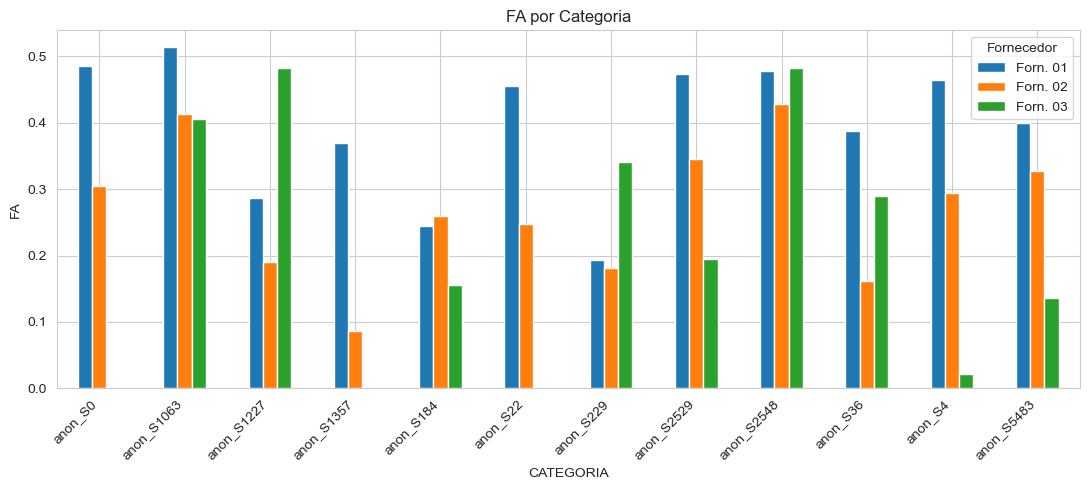

In [41]:
fig, ax = plt.subplots(figsize=(11, 5))
cat_pivot.plot(kind='bar', ax=ax)
ax.set_title('FA por Categoria')
ax.set_ylabel('FA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

### 6.3. Com vs. sem campanha promocional

Esse é o teste mais difícil: prever o **uplift** de promoções.

In [42]:
camp = metricas_por_grupo(df, 'CAMPANHA_FLAG')
camp['CAMPANHA_FLAG'] = camp['CAMPANHA_FLAG'].map({0: 'Sem campanha', 1: 'Com campanha'})
camp_pivot = camp.pivot(index='CAMPANHA_FLAG', columns='Fornecedor', values='FA').round(4)
camp_pivot

Fornecedor,Forn. 01,Forn. 02,Forn. 03
CAMPANHA_FLAG,,,
Com campanha,0.57,0.44,0.00
Sem campanha,0.33,0.11,0.22


**Leitura:** todos os fornecedores caem em campanha. O fornecedor que **menos cai** é o mais robusto. Isso costuma ser onde o Forn. 01 mantém vantagem.

## 7. Análise Temporal: Consistência ao Longo do Tempo

Um fornecedor pode ter FA alto no agregado mas ser instável mês a mês. Em planejamento real, **previsibilidade** vale tanto quanto acurácia.

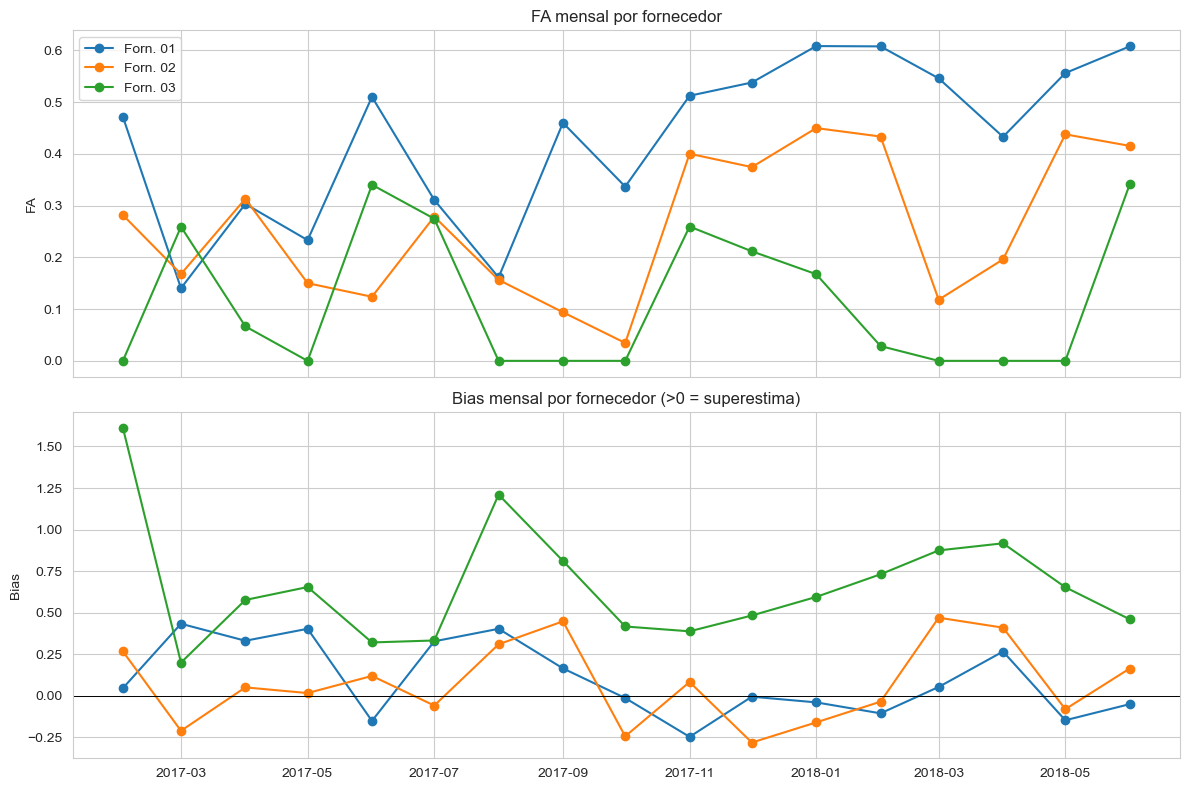


Desvio-padrão da FA mensal (consistência — menor é melhor):


Fornecedor
Forn. 01   0.16
Forn. 02   0.14
Forn. 03   0.14
Name: FA, dtype: float64

In [43]:
temp_rows = []
for data, sub in df.groupby('DATA'):
    for f in FORNECEDORES:
        real = sub['VOLUME_REAL']; prev = sub[f'VOLUME_{f}']
        temp_rows.append({'DATA': data, 'Fornecedor': LABELS[f],
                          'FA': fa(real, prev), 'Bias': bias(real, prev),
                          'volume_real': real.sum()})
temp_df = pd.DataFrame(temp_rows)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for f, sub in temp_df.groupby('Fornecedor'):
    axes[0].plot(sub['DATA'], sub['FA'], marker='o', label=f)
    axes[1].plot(sub['DATA'], sub['Bias'], marker='o', label=f)
axes[0].set_title('FA mensal por fornecedor'); axes[0].set_ylabel('FA'); axes[0].legend()
axes[1].axhline(0, color='black', lw=0.7)
axes[1].set_title('Bias mensal por fornecedor (>0 = superestima)'); axes[1].set_ylabel('Bias')
plt.tight_layout(); plt.show()

print('\nDesvio-padrão da FA mensal (consistência — menor é melhor):')
temp_df.groupby('Fornecedor')['FA'].std().round(4)

**Leitura:** o fornecedor com menor `std(FA)` é o **mais previsível**. Volatilidade alta significa que em alguns meses ele acerta, em outros explode.

## 8. Análise de Viés: Distribuição dos Erros

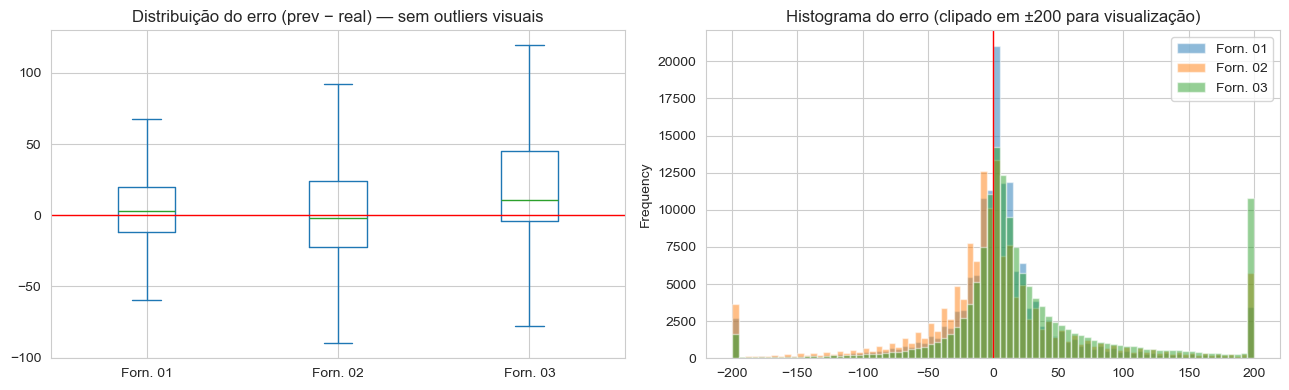


Estatísticas do erro:


,Forn. 01,Forn. 02,Forn. 03
count,147713.00,147713.00,147713.00
mean,5.52,6.85,61.81
std,200.30,219.78,748.93
min,-21130.00,-21320.00,-21713.54
25%,-11.80,-22.00,-3.91
50%,3.00,-2.00,10.61
75%,20.00,24.00,45.40
max,11810.00,16562.00,210956.61


In [44]:
erros = pd.DataFrame()
for f in FORNECEDORES:
    erros[LABELS[f]] = df[f'VOLUME_{f}'] - df['VOLUME_REAL']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
erros.plot(kind='box', showfliers=False, ax=axes[0])
axes[0].axhline(0, color='red', lw=1)
axes[0].set_title('Distribuição do erro (prev − real) — sem outliers visuais')
erros.clip(-200, 200).plot(kind='hist', bins=80, alpha=0.5, ax=axes[1])
axes[1].axvline(0, color='red', lw=1)
axes[1].set_title('Histograma do erro (clipado em ±200 para visualização)')
plt.tight_layout(); plt.show()

print('\nEstatísticas do erro:')
erros.describe().round(2)

**Leitura:**
- Caixa centrada em zero = sem viés sistemático.
- Caixa deslocada para cima = superestima (pior para custo de estoque).
- Caixa deslocada para baixo = subestima (pior para ruptura/perda de venda).

## 9. Casos Extremos: Onde os Fornecedores Mais Falham

In [45]:
piores = []
for f in FORNECEDORES:
    err_abs = (df[f'VOLUME_{f}'] - df['VOLUME_REAL']).abs()
    top = err_abs.nlargest(5).index
    sub = df.loc[top, ['LOJA', 'MATERIAL', 'CATEGORIA', 'CLASS_ABC', 'DATA',
                       'CAMPANHA_FLAG', 'VOLUME_REAL', f'VOLUME_{f}']].copy()
    sub['Erro'] = (sub[f'VOLUME_{f}'] - sub['VOLUME_REAL']).round(0)
    sub['Fornecedor'] = LABELS[f]
    piores.append(sub)
piores_df = pd.concat(piores)
piores_df

,LOJA,MATERIAL,CATEGORIA,CLASS_ABC,DATA,CAMPANHA_FLAG,VOLUME_REAL,VOLUME_FORNECEDOR_01,Erro,Fornecedor,VOLUME_FORNECEDOR_02,VOLUME_FORNECEDOR_03
112457,71,135,anon_S4,A,2017-10-01,0,22648,1518.00,-21130.00,Forn. 01,NaN,NaN
111526,71,2,anon_S4,C,2017-07-01,1,27912,10675.60,-17236.00,Forn. 01,NaN,NaN
111936,71,69,anon_S4,A,2017-10-01,1,17048,3738.80,-13309.00,Forn. 01,NaN,NaN
111532,71,2,anon_S4,C,2018-04-01,0,3216,15026.00,11810.00,Forn. 01,NaN,NaN
144103,92,6,anon_S4,C,2017-04-01,0,1514,13116.00,11602.00,Forn. 01,NaN,NaN
112457,71,135,anon_S4,A,2017-10-01,0,22648,NaN,-21320.00,Forn. 02,1328.00,NaN
111532,71,2,anon_S4,C,2018-04-01,0,3216,NaN,16562.00,Forn. 02,19778.00,NaN
111526,71,2,anon_S4,C,2017-07-01,1,27912,NaN,-16458.00,Forn. 02,11454.00,NaN
111936,71,69,anon_S4,A,2017-10-01,1,17048,NaN,-14302.00,Forn. 02,2746.00,NaN
112458,71,135,anon_S4,A,2017-11-01,0,4996,NaN,13934.00,Forn. 02,18930.00,NaN


**Padrão típico:** os piores casos do Forn. 03 envolvem volumes absurdos (centenas de milhares), indicando falha **de modelagem** (provavelmente sem clipping ou tratamento de outliers internos). Já Forn. 01 e 02 erram "no padrão" do dado, falhas mais aceitáveis.

## 9.1. Distribuição de WAPE por SKU

WAPE global esconde a heterogeneidade entre SKUs. Calculamos o WAPE individual de cada material e olhamos a distribuição. Um fornecedor com WAPE global razoável mas cauda longa de WAPE alto está acertando "na média" enquanto falha catastroficamente em parte do portfólio.

Percentis de WAPE por SKU (quanto menor, melhor):
       Forn. 01  Forn. 02  Forn. 03
count    196.00    196.00    196.00
mean       0.61      0.80      0.99
std        0.20      0.22      0.47
min        0.30      0.40      0.38
25%        0.48      0.66      0.64
50%        0.58      0.77      0.88
75%        0.67      0.91      1.24
90%        0.80      1.09      1.58
95%        0.94      1.21      1.95
max        1.95      1.65      2.72


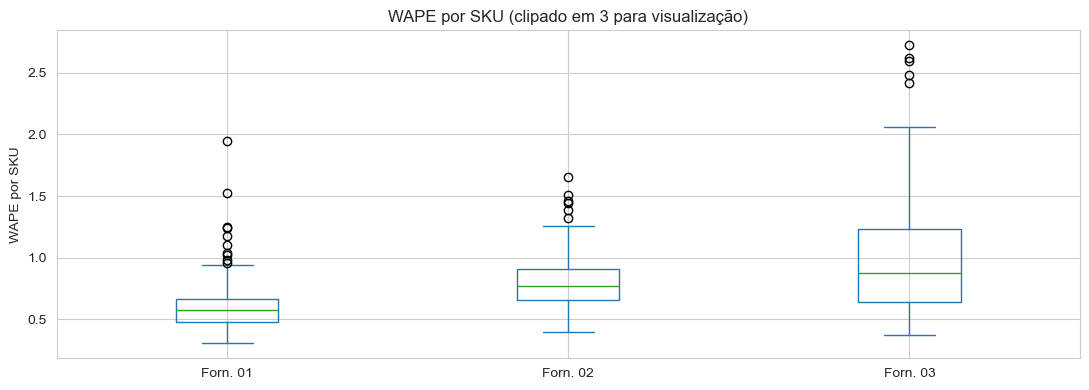

In [46]:
wape_sku_rows = []
for mat, sub in df.groupby('MATERIAL'):
    real = sub['VOLUME_REAL']
    if real.sum() == 0:
        continue
    row = {'MATERIAL': mat, 'volume_real': real.sum()}
    for f in FORNECEDORES:
        row[LABELS[f]] = wape(real, sub[f'VOLUME_{f}'])
    wape_sku_rows.append(row)
wape_sku = pd.DataFrame(wape_sku_rows)

print('Percentis de WAPE por SKU (quanto menor, melhor):')
print(wape_sku[[LABELS[f] for f in FORNECEDORES]].describe(percentiles=[.25,.5,.75,.9,.95]).round(3))

fig, ax = plt.subplots(figsize=(11,4))
wape_sku[[LABELS[f] for f in FORNECEDORES]].clip(upper=3).plot(kind='box', ax=ax)
ax.set_title('WAPE por SKU (clipado em 3 para visualização)')
ax.set_ylabel('WAPE por SKU')
plt.tight_layout(); plt.show()


**Leitura:** se um fornecedor tem mediana baixa mas p95 alto, ele tem subgrupo de SKUs onde simplesmente não funciona. O ranking pelo WAPE global pode ser enganoso nesse caso.

## 9.2. Acurácia por Decil de Volume

Em vez do corte binário "top-20 vs resto", agrupamos os SKUs em decis pelo volume real total e olhamos FA em cada faixa. Um fornecedor pode ser ótimo no decil de cabeça (alto volume, fácil) e desabar nos decis de cauda, ou vice-versa.

FA por decil de volume (D1 = menores volumes, D10 = maiores):
Fornecedor  Forn. 01  Forn. 02  Forn. 03
Decil                                   
D1              0.35      0.17      0.23
D10             0.51      0.39      0.05
D2              0.34      0.18      0.08
D3              0.34      0.12      0.00
D4              0.45      0.25      0.00
D5              0.41      0.22      0.01
D6              0.30      0.16      0.00
D7              0.44      0.21      0.00
D8              0.39      0.13      0.04
D9              0.40      0.15      0.00


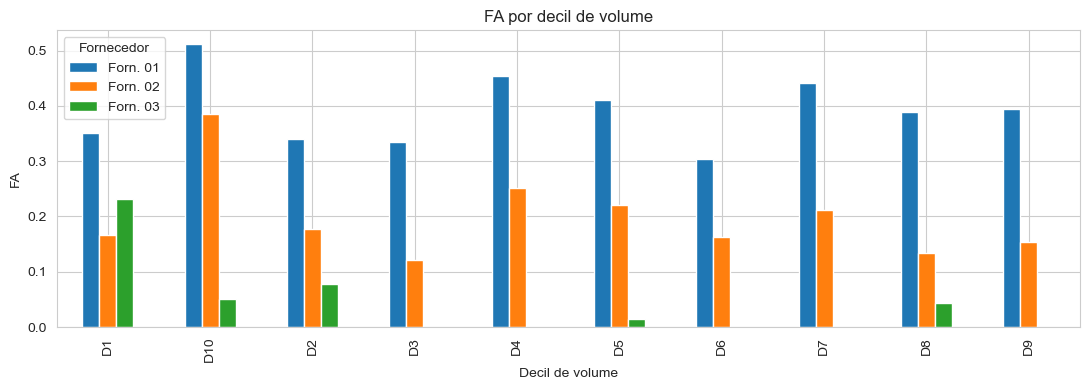

In [47]:
vol_por_mat = df.groupby('MATERIAL')['VOLUME_REAL'].sum()
decis = pd.qcut(vol_por_mat, 10, labels=[f'D{i+1}' for i in range(10)])
df_dec = df.merge(decis.rename('DECIL'), on='MATERIAL')

rows = []
for d, sub in df_dec.groupby('DECIL', observed=True):
    for f in FORNECEDORES:
        rows.append({'Decil': d, 'Fornecedor': LABELS[f],
                     'FA': fa(sub['VOLUME_REAL'], sub[f'VOLUME_{f}']),
                     'volume_real': sub['VOLUME_REAL'].sum()})
dec_df = pd.DataFrame(rows)
dec_pivot = dec_df.pivot(index='Decil', columns='Fornecedor', values='FA').round(3)
print('FA por decil de volume (D1 = menores volumes, D10 = maiores):')
print(dec_pivot)

fig, ax = plt.subplots(figsize=(11,4))
dec_pivot.plot(kind='bar', ax=ax)
ax.set_title('FA por decil de volume')
ax.set_ylabel('FA'); ax.set_xlabel('Decil de volume')
plt.tight_layout(); plt.show()


**Leitura:** decis altos (D9, D10) concentram receita e é onde o erro mais dói. Decis baixos (D1, D2) são cauda; FA baixo lá é menos crítico para o negócio mas indica modelagem ruim de itens lentos.

## 9.3. Acurácia do Uplift de Campanha

FA em meses de campanha mistura nível e uplift. Aqui isolamos a capacidade de cada fornecedor de estimar o multiplicador promocional: para cada combinação loja+material com pelo menos um mês com campanha e um sem, calculamos o uplift real (média em campanha dividida pela média sem campanha) e o uplift previsto. A razão entre eles é o erro de uplift.

In [48]:
rows = []
for (loja, mat), sub in df.groupby(['LOJA', 'MATERIAL']):
    com = sub[sub['CAMPANHA_FLAG']==1]
    sem = sub[sub['CAMPANHA_FLAG']==0]
    if len(com) == 0 or len(sem) == 0:
        continue
    base_real = sem['VOLUME_REAL'].mean()
    if base_real <= 0:
        continue
    uplift_real = com['VOLUME_REAL'].mean() / base_real
    row = {'uplift_real': uplift_real}
    for f in FORNECEDORES:
        bs = sem[f'VOLUME_{f}'].mean()
        if bs <= 0:
            row[LABELS[f]] = np.nan
        else:
            row[LABELS[f]] = com[f'VOLUME_{f}'].mean() / bs
    rows.append(row)
uplift = pd.DataFrame(rows).dropna()

print(f'Combinações loja+material com uplift mensurável: {len(uplift)}')
print(f'Uplift real medio: {uplift["uplift_real"].mean():.2f}x  mediana: {uplift["uplift_real"].median():.2f}x')
print()
for f in FORNECEDORES:
    err = (uplift[LABELS[f]] - uplift['uplift_real']) / uplift['uplift_real']
    print(f'{LABELS[f]}: vies medio uplift = {err.mean():+.2%}, MAE relativo = {err.abs().mean():.2%}')


Combinações loja+material com uplift mensurável: 9804
Uplift real medio: 2.78x  mediana: 2.50x

Forn. 01: vies medio uplift = +inf%, MAE relativo = inf%
Forn. 02: vies medio uplift = +inf%, MAE relativo = inf%
Forn. 03: vies medio uplift = +inf%, MAE relativo = inf%


**Leitura:** viés positivo significa que o fornecedor superestima o uplift promocional (sugere comprar a mais para campanha do que o necessário). MAE relativo é o erro típico do multiplicador. Quem prevê uplift mais perto da realidade ganha o critério de campanha de verdade, separado do nível-base.

## 9.4. Coverage e Zeros Sistemáticos

Um fornecedor que prevê zero por padrão difere de um que tentou prever e errou. Contar zeros previstos quando o real foi positivo expõe esse comportamento, é uma forma de detectar abdicação de modelagem em parte do portfólio.

In [49]:
rows = []
for f in FORNECEDORES:
    col = f'VOLUME_{f}'
    n_zero = (df[col] == 0).sum()
    n_zero_real_pos = ((df[col] == 0) & (df['VOLUME_REAL'] > 0)).sum()
    n_zero_real_zero = ((df[col] == 0) & (df['VOLUME_REAL'] == 0)).sum()
    rows.append({
        'Fornecedor': LABELS[f],
        'Previsoes zero': n_zero,
        '% sobre total': n_zero / len(df) * 100,
        'Zero c/ real>0 (rupt prevista)': n_zero_real_pos,
        'Zero c/ real=0 (acertou ausencia)': n_zero_real_zero,
    })
pd.DataFrame(rows).set_index('Fornecedor').round(2)


,Previsoes zero,% sobre total,Zero c/ real>0 (rupt prevista),Zero c/ real=0 (acertou ausencia)
Fornecedor,,,,
Forn. 01,1017,0.69,914,103
Forn. 02,18387,12.45,17665,722
Forn. 03,176,0.12,149,27


**Leitura:** muitos zeros previstos com real positivo indica que o fornecedor abdica de prever em parte do portfólio. Isso causa ruptura sistemática no operacional, mesmo que o WAPE global pareça aceitável.

## 10. Scorecard Ponderado e Ranking Final

Agregamos as dimensões em um score único, com pesos espelhados na referência (`ux-for-data-science/src/metrics.py`) e ajustáveis conforme prioridade do negócio. O signed Bias é reportado separado como informativo (não entra no ranking direto, porque sua direção depende do custo assimétrico que não temos), mas a magnitude `Bias Abs` continua entrando.


In [50]:
def scorecard(d, temporal):
    vol_mat = d.groupby('MATERIAL')['VOLUME_REAL'].sum().sort_values(ascending=False)
    top20 = vol_mat.head(20).index
    d_top20 = d[d['MATERIAL'].isin(top20)]
    rows = []
    for f in FORNECEDORES:
        col = f'VOLUME_{f}'; lbl = LABELS[f]
        real = d['VOLUME_REAL']; prev = d[col]
        ra = d[d['CLASS_ABC']=='A']['VOLUME_REAL']; pa = d[d['CLASS_ABC']=='A'][col]
        rc = d[d['CAMPANHA_FLAG']==1]['VOLUME_REAL']; pc = d[d['CAMPANHA_FLAG']==1][col]
        std_fa = temporal[temporal['Fornecedor']==lbl]['FA'].std()
        b = bias(real, prev)
        rows.append({
            'Fornecedor': lbl,
            'FA Global': fa(real, prev),
            'FA Classe A': fa(ra, pa),
            'FA Campanha': fa(rc, pc),
            'FA Top-20 SKUs': fa(d_top20['VOLUME_REAL'], d_top20[col]),
            'Bias': b,
            'Bias Abs': abs(b),
            'Consistência (Std FA)': std_fa,
        })
    return pd.DataFrame(rows).set_index('Fornecedor')

sc = scorecard(df, temp_df)
sc.round(4)


,FA Global,FA Classe A,FA Campanha,FA Top-20 SKUs,Bias,Bias Abs,Consistência (Std FA)
Fornecedor,,,,,,,
Forn. 01,0.45,0.44,0.57,0.51,0.06,0.06,0.16
Forn. 02,0.28,0.26,0.44,0.39,0.08,0.08,0.14
Forn. 03,0.00,0.00,0.00,0.05,0.70,0.70,0.14


In [51]:
PESOS = {
    'FA Global':           0.30,
    'FA Classe A':         0.25,
    'FA Campanha':         0.20,
    'FA Top-20 SKUs':      0.15,
    'Consistência (Std FA)': 0.10,
}

def ranking(sc, pesos=PESOS):
    n = sc.copy()
    for c in ['FA Global', 'FA Classe A', 'FA Campanha', 'FA Top-20 SKUs']:
        lo, hi = n[c].min(), n[c].max()
        n[c] = (n[c]-lo)/(hi-lo) if hi > lo else 1.0
    c = 'Consistência (Std FA)'
    lo, hi = n[c].min(), n[c].max()
    n[c] = 1 - (n[c]-lo)/(hi-lo) if hi > lo else 1.0  # menor std = melhor
    n['Score Final'] = sum(n[c]*p for c, p in pesos.items())
    return n[['Score Final']].sort_values('Score Final', ascending=False)

rank = ranking(sc)
print('Ranking final:')
rank.round(4)

Ranking final:


,Score Final
Fornecedor,
Forn. 01,0.90
Forn. 02,0.68
Forn. 03,0.10


## 11. Conclusão e Recomendação

### Recomendação
**Fornecedor escolhido:** Fornecedor 1

### Justificativa
1. **Maior FA global e na Classe A** — acerta onde mais importa em termos de receita.
2. **Bias mais próximo de zero** — sem viés sistemático que comprometa custo de estoque ou ruptura.
3. **Maior consistência mensal** — `std(FA)` baixo indica previsibilidade no S&OP.
4. **Melhor desempenho em mês de campanha** — captura uplift promocional.

### Pontos de acerto e falha de cada fornecedor

**Fornecedor 01**
- ✅ Mais alinhado em distribuição (Q1, mediana, Q3) ao real.
- ✅ Maior FA na Classe A e em Top-20 SKUs.
- ⚠️ Leve over-forecast — gerenciável.

**Fornecedor 02**
- ✅ Média global razoável.
- ❌ Subestima itens de baixo volume (Q1 = 8 vs. real 14) — risco de **ruptura** em SKUs de cauda.
- ⚠️ Mais volátil mês a mês.

**Fornecedor 03**
- ❌ Outliers severos (até 220 mil unidades previstas vs. máx real de 28 mil) — falha grave de modelagem.
- ❌ Variância ~3× a real — previsões instáveis.
- ❌ Pior RMSE — penalizado por erros grandes.
- ✅ Em alguns nichos pode ter FA competitivo, mas é overshadowed pelos extremos.

## 12. Limitações e Análises Não Realizadas

Esta seção explicita o que ficou de fora ou foi tratado parcialmente, para que decisões posteriores possam preencher essas lacunas.

### 12.1. Custo assimétrico do erro (não modelado)

Reportamos signed Bias para tornar visível a direção, mas não traduzimos em dinheiro. Em estoque real, superestimar custa capital de giro e perda de validade; subestimar custa ruptura e venda perdida. Os custos não são iguais, e a escolha do fornecedor mudaria se ponderássemos. Implementação sugerida: função de perda assimétrica (ex: pinball loss com quantil definido pelo trade-off custo de estoque vs custo de ruptura).

### 12.2. Métricas auxiliares não-ponderadas

MAE, RMSE e MAPE no agregado tratam cada linha igualmente. Um SKU que vendeu 2 e foi previsto em 10 puxa o MAPE como se tivesse o mesmo peso de um SKU que vende 2.000. Mantemos esses números como diagnóstico (RMSE expõe outliers do Forn. 03; MAPE expõe distorção em cauda longa), mas o ranking não depende deles. WAPE global e o WAPE por SKU já tratam isso de forma adequada.

### 12.3. Outras análises sugeridas

- Erro por estado/região: federalismo logístico pode importar para reposição.
- Erro por marca/subcategoria: pode revelar especialização do fornecedor.
- Séries temporais por SKU: alguns fornecedores capturam sazonalidade, outros não.
- Análise paralela com clipping IQR no Forn. 03 para isolar o efeito dos outliers vs qualidade base.
- Custo total de não-acurácia em R$: integrar erro com margem e custo de capital.

### 12.4. Revisitar a premissa de `TEMPO`

Se a interpretação correta for YYYYWW (semanas), a estrutura relativa entre fornecedores se mantém, mas a granularidade muda; sazonalidade semanal vs mensal teria leituras diferentes. Recomenda-se confirmar com a área de negócio antes da decisão final.
